# Question 3

## This should of course be split into different files, but you already know how to do that 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [ ]:
data = np.loadtxt('../nice_data.txt')
x = data[:, 0]
y = data[:, 1]
yerr = data[:, 2]


# Filter out NaN values
mask = ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]
yerr_clean = yerr[mask]


In [ ]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2))

def gaussian_bg(x, A, mu, sigma, C):
    return A * np.exp(-((x - mu)**2) / (2 * sigma**2)) + C

def cauchy(x, A, mu, gamma):
    return A / (1 + ((x - mu) / gamma)**2)


popt_gauss, pcov_gauss = curve_fit(gaussian, x_clean, y_clean, sigma=yerr_clean, p0=[14000, 15, 2])

popt_cauchy, pcov_cauchy = curve_fit(cauchy, x_clean, y_clean, sigma=yerr_clean, p0=[14000, 15, 2])

popt_gauss_bg, pcov_gauss_bg = curve_fit(gaussian_bg, x_clean, y_clean, sigma=yerr_clean, p0=[14000, 15, 2, 3000])

Fitting data with Gaussian, Cauchy, and Gaussian with background models


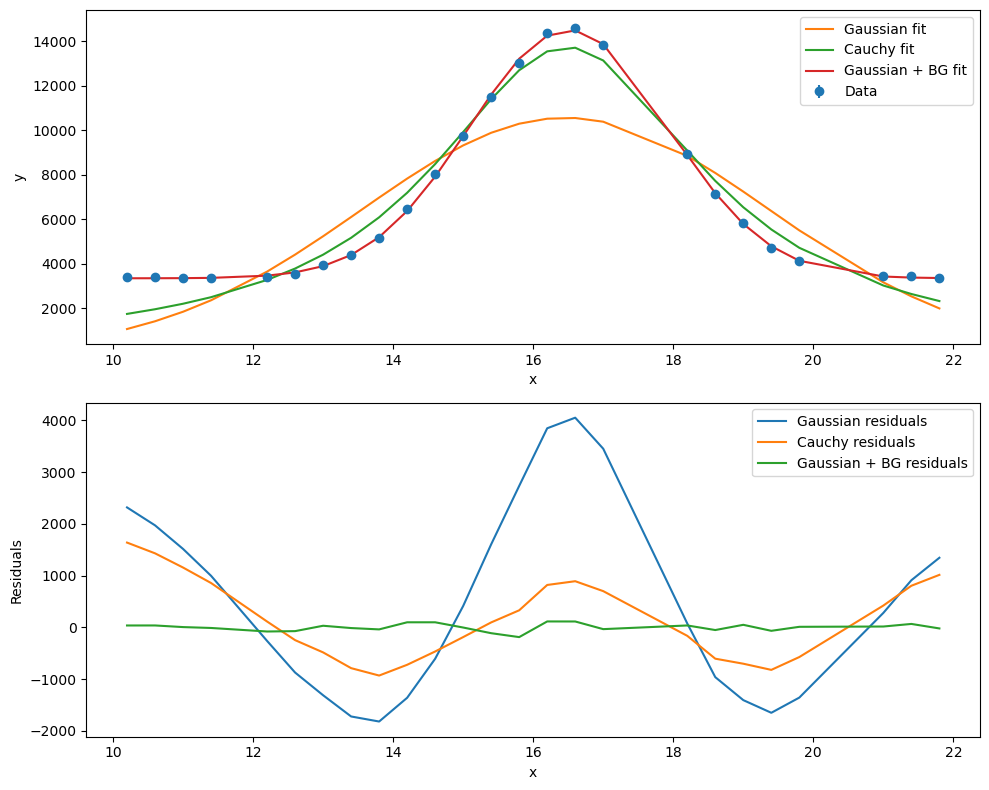

In [ ]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))


x = x_clean
y = y_clean
yerr = yerr_clean


print("Fitting data with Gaussian, Cauchy, and Gaussian with background models")
ax1.errorbar(x, y, yerr=yerr, fmt='o', label='Data')
ax1.plot(x, gaussian(x, *popt_gauss), label='Gaussian fit')
ax1.plot(x, cauchy(x, *popt_cauchy), label='Cauchy fit')
ax1.plot(x, gaussian_bg(x, *popt_gauss_bg), label='Gaussian + BG fit')
ax1.legend()
ax1.set_xlabel('x')
ax1.set_ylabel('y')

ax2.plot(x, y - gaussian(x, *popt_gauss), label='Gaussian residuals')
ax2.plot(x, y - cauchy(x, *popt_cauchy), label='Cauchy residuals')
ax2.plot(x, y - gaussian_bg(x, *popt_gauss_bg), label='Gaussian + BG residuals')
ax2.legend()
ax2.set_xlabel('x')
ax2.set_ylabel('Residuals')

plt.tight_layout()
plt.show()

# Question 6

In [34]:
class Tamagotchi:
    def __init__(self, name):
        self.name = name
        self.food = 5
        self.happiness = 5

    def status(self):
        print(f"The Tamagotchi called {self.name}")
        print(f"Food: {self.food}")
        print(f"Happiness: {self.happiness}")
        print("")

    def feed(self, amount):
        self.food += amount

    def play(self, minutes):
        self.happiness += minutes
        self.food -= minutes

    def display(self):
        if self.food < 0:
            face = "(x.x)"
            state = "Dead :("
        elif self.happiness > 10:
            face = "(^.^)"
            state = "Happy!"
        else:
            face = "(o.o)"
            state = "Normal"
        print(f"{self.name}: {face} - {state}")

    def animated_display_dance(self):
        import time
        import os
        states = [
            (r"(o.o)", "Normal"),
            (r"(^.^)", "Happy!"),
        ]*5
        for face, state in states:
            print(f"{self.name}: {face} - {state}", end='\r')
            time.sleep(1)

# Test the class
friend = Tamagotchi("Andy Goldfinch")
friend.display()
friend.status()

# Test the methods
friend.feed(3)
friend.play(2)
friend.display()
friend.status()

# Test high happiness
friend.feed(10)
friend.play(10)
friend.display()
friend.status()

# Test dead
friend.play(25)  # food will go negative
friend.display()
friend.status()

friend.animated_display_dance()

Andy Goldfinch: (o.o) - Normal
The Tamagotchi called Andy Goldfinch
Food: 5
Happiness: 5

Andy Goldfinch: (o.o) - Normal
The Tamagotchi called Andy Goldfinch
Food: 6
Happiness: 7

Andy Goldfinch: (^.^) - Happy!
The Tamagotchi called Andy Goldfinch
Food: 6
Happiness: 17

Andy Goldfinch: (x.x) - Dead :(
The Tamagotchi called Andy Goldfinch
Food: -19
Happiness: 42



# Question 8

In [23]:
import numpy as np

# Load the garden
with open('../garden.txt', 'r') as f:
    garden = [line.strip() for line in f.readlines()]

# Convert to list of lists for mutability
garden = [list(row) for row in garden]
rows = len(garden)
cols = len(garden[0])

def count_adjacent_flowers(garden, i, j):
    count = 0
    for di in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            if di == 0 and dj == 0:
                continue
            ni, nj = i + di, j + dj
            if 0 <= ni < rows and 0 <= nj < cols and garden[ni][nj] == '#':
                count += 1
    return count

def simulate_step(garden):
    new_garden = [row[:] for row in garden]
    changed = False
    for i in range(rows):
        for j in range(cols):
            if garden[i][j] == '.':
                continue
            adj = count_adjacent_flowers(garden, i, j)
            if garden[i][j] == 'L' and adj == 0:
                new_garden[i][j] = '#'
                changed = True
            elif garden[i][j] == '#' and adj >= 4:
                new_garden[i][j] = 'L'
                changed = True
    return new_garden, changed

# Print initial garden
print("Initial garden:")
for row in garden:
    print(''.join(row))

# Simulate until steady state
steps = 0
while True:
    new_garden, changed = simulate_step(garden)
    garden = new_garden
    steps += 1
    if not changed:
        break

# Count plants
plant_count = sum(row.count('#') for row in garden)

print(f"\nSteady state reached after {steps} steps.")
print(f"Total plants: {plant_count}")
print("\nFinal garden:")
for row in garden:
    print(''.join(row).replace("#","🌻").replace("L","🌱").replace(".","  "))

Initial garden:
LLLLLLLLLL.LLLLLLLLLLLLLL
LLLLLLLLLL.LLLL.LLLL.LLLL
LLLLLLLLLLLLLLLLLLLL.LLLL
LLLLLLLLLLLLLLL.LLLL.LLLL
LLLLLLLLLL.LLLLLL.LL.LLLL
LLLLLLLLLLLLLLLLLLLL.LLLL
LLLLLLLLLL.LLLL.LLLL.LLLL
..L...L.L..L.LL.....L.L..
LLLLLLLLLLLLLLL.LLLLLLLLL
LLLLLLLLLL.LLLL.LLLLLLLLL
LLLLLLLLLL.LLLL.LLLLLLLLL
LLLLLLLLLL.LLLL.LLLL.LLLL
LLLLLLLLLL.LLLLLLLLLLLLLL
LLLLLLLLLL.LLLLLLLLLLLLLL
.....LLL....L..L.L..L.L..
LLLLLLLLLL.LLLLLLLLL.LLLL
LLLLLLLLLL.LLLL.L.LLLLLLL
LLLLLLLLLLLLLLLLLLLLLLLLL
LLLLLLLLLLLLLLL.LLL.LLLLL
..L.L.LL.L..LL..L..LL.L..
LLLLLL.LLL.LLLL.LLLLLLLLL
LLLLLLLLLL.LLLL.LLLL.L.LL
LLLLLLLLLL.LLLL.LLLL.LLLL
LLLLLLLLLL.LLLL.LLLL.LLLL
LL.L.L.L.....L..L...L.L..

Steady state reached after 23 steps.
Total plants: 167

Final garden:
🌻🌱🌻🌱🌻🌻🌱🌻🌱🌻  🌻🌱🌻🌱🌻🌱🌻🌻🌱🌻🌱🌻🌱🌻
🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱  🌱🌱🌱🌱  🌱🌱🌱🌱  🌱🌱🌱🌱
🌻🌱🌻🌱🌻🌱🌻🌱🌻🌱🌻🌱🌻🌻🌱🌻🌱🌻🌱🌻  🌻🌻🌱🌻
🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱  🌱🌱🌱🌱  🌱🌱🌱🌱
🌻🌱🌻🌱🌻🌱🌻🌱🌻🌱  🌻🌱🌱🌻🌱🌻  🌱🌻  🌻🌻🌱🌻
🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱🌱  🌱🌱🌱🌱
🌻🌱🌻🌱🌻🌱🌻🌱🌻🌻  🌻🌱🌱🌻  🌱🌻🌱🌻  🌻🌻🌱🌻
    🌻      🌱  🌱    🌱  🌱🌱          🌱  🌱    
🌻🌱🌱🌱🌻🌱🌻🌱🌻🌱🌻🌱🌻🌱🌻  🌻🌱🌻🌱🌻🌱🌻